<a href="https://colab.research.google.com/github/wnstj1126-debug/-/blob/main/M0_FEMTO_Baseline_v1_baseline%EA%B3%A0%EC%A0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeepBind 예지보전 — 2단계: FEMTO M0 재현 (9특징 Mahalanobis baseline 고정)

**목적**: CLAUDE.md §3 M0의 5/6 성적표를 baseline으로 재현·고정  
**원칙**: M1/M2와 동일 후처리(K=6, CONSEC=5) 적용 → 공정 비교 잣대  
**근거**: CLAUDE.md §3(M0 정의), §4(프레임), §5(cadence), §6(FEMTO=진짜 M0)

| 항목 | 값 |
|:---|:---|
| 데이터셋 | FEMTO (H축 단일, COL_H=4 확정) |
| 알고리즘 | 9특징 Mahalanobis + 적응형 등록 |
| 기대 성적 | 5/6 탐지 성공, 등록구간 오경보 0 |
| 산출물 | `m0_baseline_result.csv` |

### 실행 순서
셀A(Drive 마운트·설정) → 셀B(유틸 함수) → 셀C(전체 실행) → 셀D(시각화) → 셀E(결과 저장·판정) → **셀F(baseline 정식 고정)**


In [7]:
# ============================================================
# 셀 A — Drive 마운트 + 설정 (CLAUDE.md §4/§5/§6 준거)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# Google Drive 마운트 (Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE = '/content/drive/MyDrive'
except Exception:
    DRIVE = '/content/drive/MyDrive'
    print('(Colab 아님 또는 이미 마운트됨)')

# ── FEMTO 경로 (DataInventory_v1 확정값) ─────────────────
FEMTO_ROOT = (DRIVE
    + '/Colab Notebooks/3.RunToFailure_Raw_Data'
    + '/PRONOSTIA_FEMTO_Bearing')

SAVE_DIR = DRIVE + '/Colab Notebooks/field_iis3dwb/'

# ── 하이퍼파라미터 (CLAUDE.md §4/§5 확정값) ──────────────
FEMTO_FS  = 25600     # native fs (Hz)
COL_H     = 4         # H축 인덱스 (확정: head[4]=0.092 실측)
K         = 6.0       # Mahalanobis 임계 (표준편차 배수)
CONSEC    = 5         # 연속 이탈 판정 프레임 수
REG_MIN   = 90        # baseline 최소 등록 프레임 (적응형)
REG_MAX   = 600       # baseline 최대 등록 프레임 (적응형)
FEMTO_INTERVAL_SEC = 10  # 파일 간격 10초 (스냅샷)

FEATURE_NAMES = ['RMS','Peak','Crest','Kurtosis','Skew','P2P','Std','EnvRMS','HF_ratio']

import os
os.makedirs(SAVE_DIR, exist_ok=True)

print('설정 완료')
print(f'  FEMTO_ROOT: {FEMTO_ROOT}')
print(f'  SAVE_DIR:   {SAVE_DIR}')
print(f'  K={K}, CONSEC={CONSEC}, REG_MIN={REG_MIN}, REG_MAX={REG_MAX}')
print(f'  COL_H={COL_H} (H축 확정)')
exists = Path(FEMTO_ROOT).exists()
print(f'  경로 존재: {"✅" if exists else "❌ 수정 필요"}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
설정 완료
  FEMTO_ROOT: /content/drive/MyDrive/Colab Notebooks/3.RunToFailure_Raw_Data/PRONOSTIA_FEMTO_Bearing
  SAVE_DIR:   /content/drive/MyDrive/Colab Notebooks/field_iis3dwb/
  K=6.0, CONSEC=5, REG_MIN=90, REG_MAX=600
  COL_H=4 (H축 확정)
  경로 존재: ✅


In [8]:
# ============================================================
# 셀 B — 유틸 함수 정의
#   - extract_features: 9특징 추출 (기존 OnlineSim_FEMTO_v3와 동일)
#   - load_bearing_features: 베어링 폴더 → 시간순 특징 시퀀스
#   - mahal: Mahalanobis 거리
#   - register_and_detect: 등록 + 이탈 탐지
# ============================================================

from scipy.stats import kurtosis, skew
from scipy.signal import hilbert

# ── 9특징 추출 ────────────────────────────────────────────
def extract_features(sig, fs=FEMTO_FS):
    """
    입력: 1D 신호 배열 (H축 단일)
    출력: 9D 특징벡터 [RMS, Peak, Crest, Kurt, Skew, P2P, Std, EnvRMS, HF_ratio]
    기존 OnlineSim_FEMTO_v3.ipynb extract_features와 동일 구현.
    """
    x     = sig.astype(np.float64)
    rms   = np.sqrt(np.mean(x**2))
    peak  = np.max(np.abs(x))
    crest = peak / (rms + 1e-12)
    kurt  = kurtosis(x)
    sk    = skew(x)
    p2p   = np.ptp(x)
    std   = np.std(x)
    env   = np.abs(hilbert(x))
    env_rms = np.sqrt(np.mean((env - env.mean())**2))
    fft_mag = np.abs(np.fft.rfft(x))
    freqs   = np.fft.rfftfreq(len(x), 1 / fs)
    hf      = np.sum(fft_mag[freqs > 2000]**2) / (np.sum(fft_mag**2) + 1e-12)
    return np.array([rms, peak, crest, kurt, sk, p2p, std, env_rms, hf])


# ── 베어링 시퀀스 로드 ────────────────────────────────────
def load_bearing_features(bearing_dir):
    """
    한 베어링 폴더의 acc_*.csv → 시간순 9특징 시퀀스
    반환: feats (N, 9), fnames (N,)
    """
    files = sorted(Path(bearing_dir).glob('acc_*.csv'))
    feats = []
    for f in files:
        try:
            arr = np.loadtxt(str(f), delimiter=',')
        except Exception:
            arr = np.loadtxt(str(f), delimiter=';')
        feats.append(extract_features(arr[:, COL_H]))
    return np.array(feats), [f.name for f in files]


# ── Mahalanobis 거리 ──────────────────────────────────────
def mahal(x, mu, inv_cov):
    d = x - mu
    return float(np.sqrt(d @ inv_cov @ d))


# ── 등록 + 이탈 탐지 ──────────────────────────────────────
def register_and_detect(feats, k=K, consec=CONSEC,
                         reg_min=REG_MIN, reg_max=REG_MAX):
    """
    1) 앞 1/4 (min=reg_min, max=reg_max) 구간을 정상 baseline으로 등록
    2) 전체 Mahalanobis 거리 계산
    3) 임계(등록 평균 + K×표준편차) 초과가 CONSEC 연속 → 최초 알람 반환

    반환 dict:
      n_reg      : 등록 프레임 수
      thr        : 임계값
      dists      : 전체 거리 배열 (N,)
      alarm_idx  : 최초 알람 프레임 인덱스 (None=미탐지)
      N          : 전체 프레임 수
      reg_far    : 등록구간 임계초과 비율 (오경보 진단용)
    """
    N     = len(feats)
    n_reg = min(reg_max, max(reg_min, N // 4))

    reg = feats[:n_reg]
    mu  = reg.mean(axis=0)
    cov = np.cov(reg, rowvar=False)
    # 수치 안정화 (shrinkage)
    cov += np.eye(cov.shape[0]) * 1e-6 * np.trace(cov) / cov.shape[0]
    inv = np.linalg.pinv(cov)

    # 등록구간 거리 분포 → 임계
    d_reg = np.array([mahal(f, mu, inv) for f in reg])
    thr   = d_reg.mean() + k * d_reg.std()

    # 전체 거리
    dists = np.array([mahal(f, mu, inv) for f in feats])
    over  = dists > thr

    # CONSEC 연속 초과 탐색 (등록구간 제외)
    alarm_idx = None
    run = 0
    for i in range(n_reg, N):
        run = run + 1 if over[i] else 0
        if run >= consec:
            alarm_idx = i - consec + 1
            break

    reg_far = float(over[:n_reg].mean())

    return {
        'n_reg': n_reg, 'thr': thr, 'dists': dists,
        'alarm_idx': alarm_idx, 'N': N, 'reg_far': reg_far,
    }


print('유틸 함수 정의 완료')
print('  extract_features / load_bearing_features / mahal / register_and_detect')

유틸 함수 정의 완료
  extract_features / load_bearing_features / mahal / register_and_detect


In [9]:
# ============================================================
# 셀 C — 전체 실행: 모든 베어링 M0 재현
# ============================================================

def run_m0(femto_root=FEMTO_ROOT):
    # 베어링 폴더 자동 탐색
    bearing_dirs = sorted([
        p for p in Path(femto_root).rglob('Bearing*')
        if p.is_dir() and list(p.glob('acc_*.csv'))
    ])
    print(f'발견된 베어링: {len(bearing_dirs)}개')
    for bd in bearing_dirs:
        n = len(list(bd.glob('acc_*.csv')))
        print(f'  {bd.name}: {n}개 파일')
    print()

    rows = []
    results_raw = {}  # 시각화용

    for bd in bearing_dirs:
        feats, fnames = load_bearing_features(bd)
        name = bd.name

        if len(feats) < REG_MIN + CONSEC:
            print(f'  [{name}] 프레임 부족({len(feats)}) → 스킵')
            continue

        r = register_and_detect(feats)
        results_raw[name] = r
        results_raw[name]['feats'] = feats

        # 리드타임 계산 (파일간 10초)
        if r['alarm_idx'] is not None:
            lead_f   = r['N'] - r['alarm_idx']
            lead_sec = lead_f * FEMTO_INTERVAL_SEC
            lead_h   = lead_sec / 3600
            life_pct = r['alarm_idx'] / r['N'] * 100
            status   = f'✅ 탐지'
        else:
            lead_f = lead_sec = lead_h = 0
            life_pct = 100.0
            status   = '❌ 미탐지'

        reg_ok = '✅' if r['reg_far'] == 0 else f'⚠️ {r["reg_far"]:.3f}'

        rows.append({
            'bearing':     name,
            'N':           r['N'],
            'n_reg':       r['n_reg'],
            'alarm_idx':   r['alarm_idx'],
            'life_pct':    round(life_pct, 1),
            'lead_frames': lead_f,
            'lead_hours':  round(lead_h, 1),
            'reg_FAR':     round(r['reg_far'], 4),
            'reg_ok':      reg_ok,
            'status':      status,
        })

        print(f'  [{name}] {status} | '
              f'알람={r["alarm_idx"]}/{r["N"]} ({life_pct:.1f}%) | '
              f'리드타임={lead_h:.1f}h | 등록오경보={reg_ok}')

    df = pd.DataFrame(rows)
    n_ok  = df['status'].str.startswith('✅').sum()
    n_reg_ok = (df['reg_FAR'] == 0).sum()

    print(f'\n{"="*55}')
    print(f'[M0 baseline 성적표]')
    print(f'{"="*55}')
    print(f'  탐지 성공:       {n_ok}/{len(df)}')
    print(f'  등록오경보 0:    {n_reg_ok}/{len(df)}')
    print(f'{"="*55}')
    print(df[['bearing','N','n_reg','alarm_idx','life_pct',
              'lead_hours','reg_ok','status']].to_string(index=False))

    return df, results_raw


# 실행
m0_df, m0_raw = run_m0()

발견된 베어링: 28개
  Bearing1_3: 590개 파일
  Bearing1_4: 1139개 파일
  Bearing1_5: 2302개 파일
  Bearing1_6: 2232개 파일
  Bearing1_7: 1502개 파일
  Bearing2_3: 1202개 파일
  Bearing2_4: 612개 파일
  Bearing2_5: 2002개 파일
  Bearing2_6: 572개 파일
  Bearing2_7: 172개 파일
  Bearing3_3: 1802개 파일
  Bearing1_1: 2803개 파일
  Bearing1_2: 871개 파일
  Bearing2_1: 911개 파일
  Bearing2_2: 797개 파일
  Bearing3_1: 515개 파일
  Bearing3_2: 1637개 파일
  Bearing1_3: 2375개 파일
  Bearing1_4: 1428개 파일
  Bearing1_5: 2463개 파일
  Bearing1_6: 2448개 파일
  Bearing1_7: 2259개 파일
  Bearing2_3: 1955개 파일
  Bearing2_4: 751개 파일
  Bearing2_5: 2311개 파일
  Bearing2_6: 701개 파일
  Bearing2_7: 230개 파일
  Bearing3_3: 434개 파일

  [Bearing1_3] ❌ 미탐지 | 알람=None/590 (100.0%) | 리드타임=0.0h | 등록오경보=✅
  [Bearing1_4] ✅ 탐지 | 알람=1082/1139 (95.0%) | 리드타임=0.2h | 등록오경보=⚠️ 0.004
  [Bearing1_5] ❌ 미탐지 | 알람=None/2302 (100.0%) | 리드타임=0.0h | 등록오경보=⚠️ 0.003
  [Bearing1_6] ✅ 탐지 | 알람=1630/2232 (73.0%) | 리드타임=1.7h | 등록오경보=⚠️ 0.002
  [Bearing1_7] ❌ 미탐지 | 알람=None/1502 (100.0%) | 리드타임=0.0h | 등록오경보=⚠️ 0.

/tmp/ipykernel_533/640042231.py:59: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_533/640042231.py:59: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_533/640042231.py:59: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_533/640042231.py:59: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_533/640042231.py:59: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_533/640042231.py:59: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_533/640042231.py:59: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ip

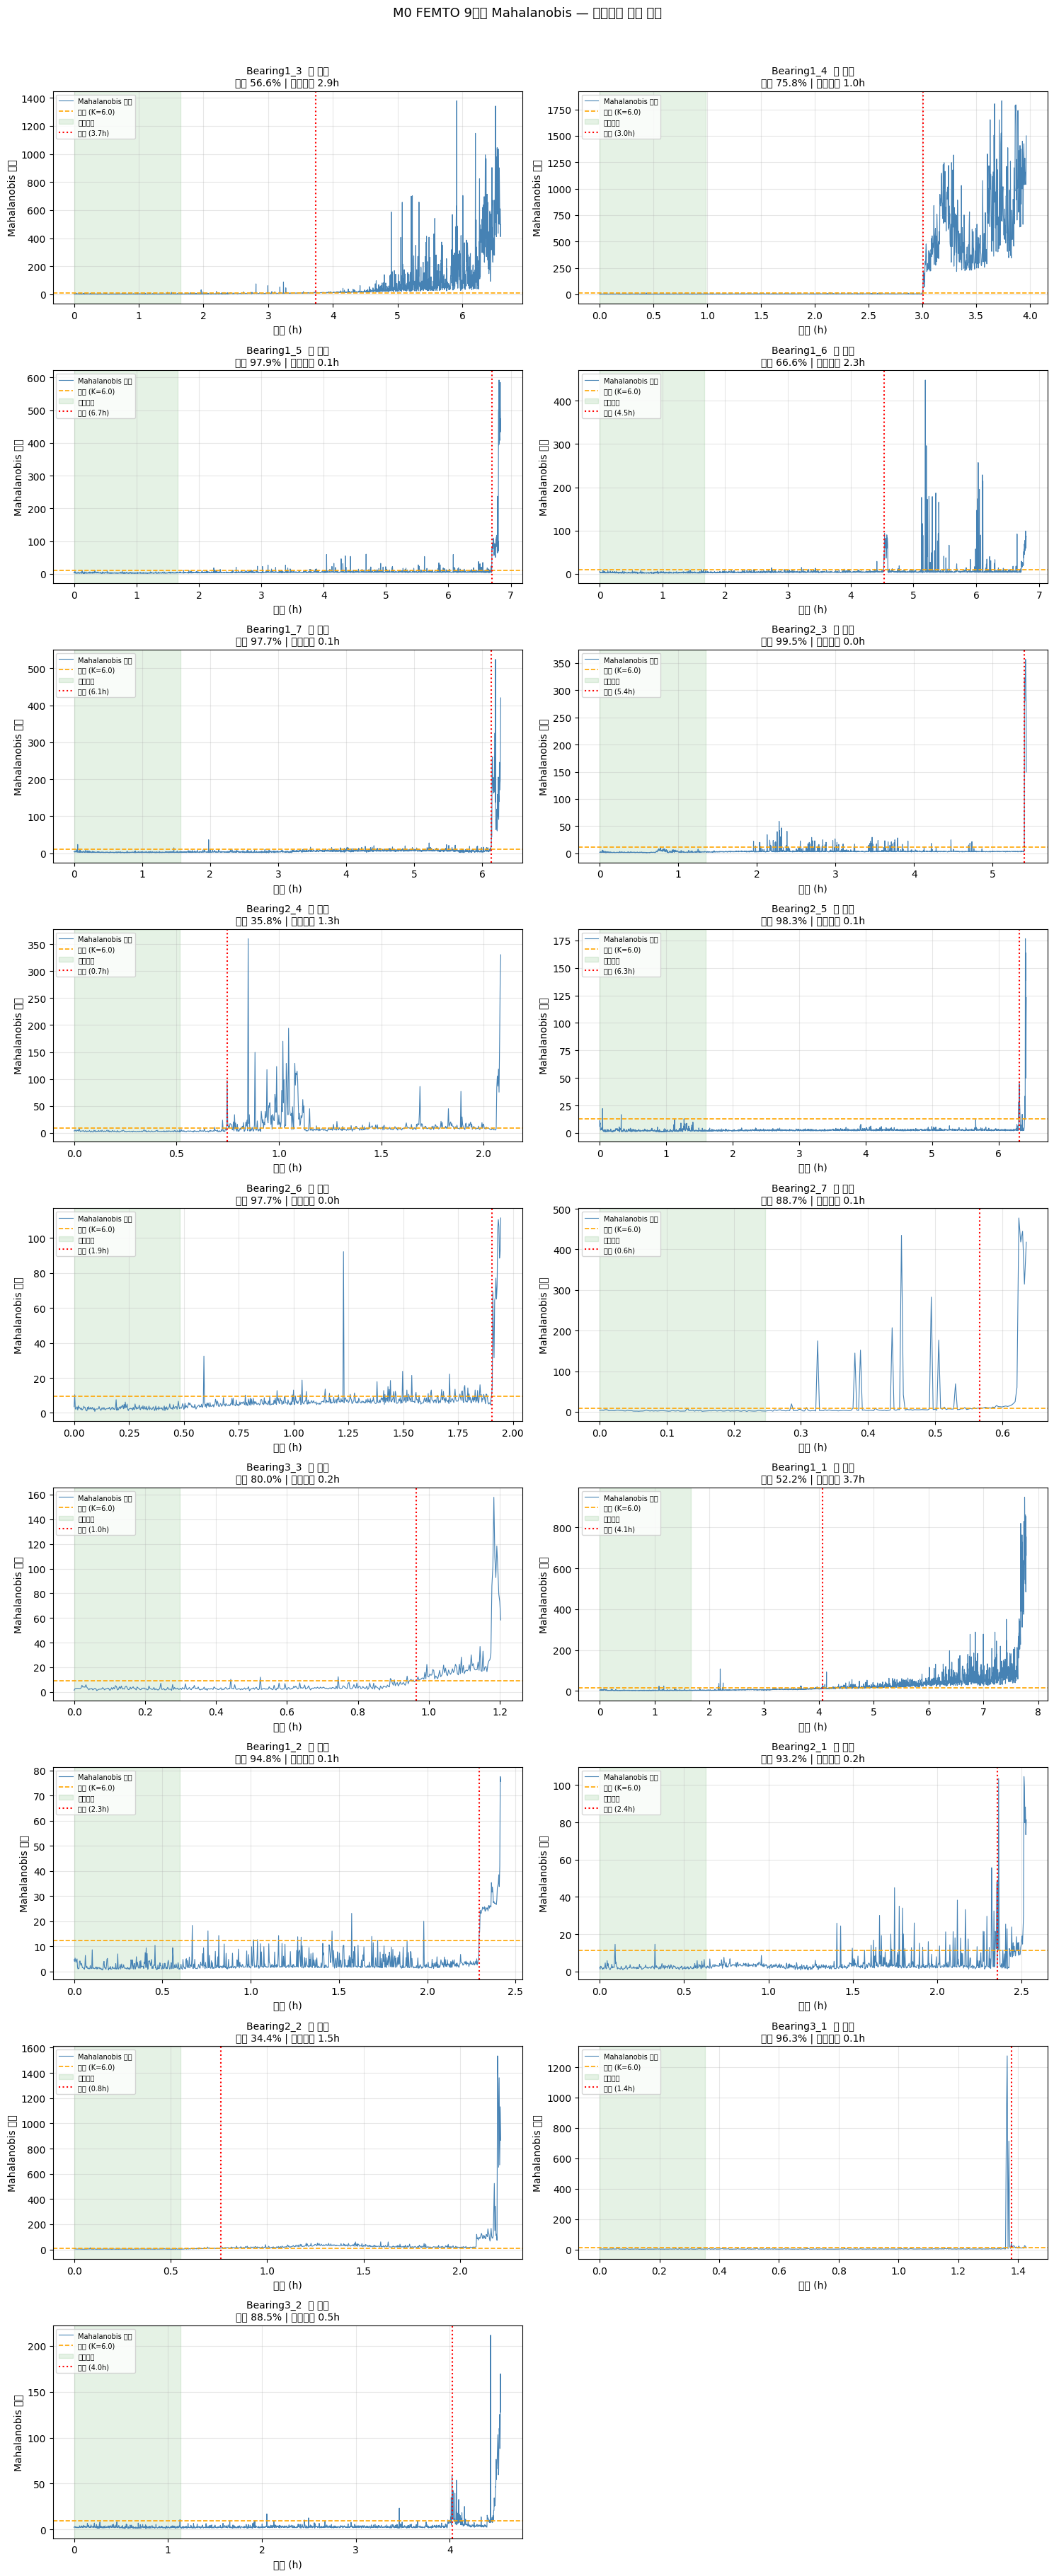

그래프 저장: /content/drive/MyDrive/Colab Notebooks/field_iis3dwb/m0_mahal_curves.png


In [10]:
# ============================================================
# 셀 D — 시각화: 베어링별 Mahalanobis 거리 곡선 + 알람 표시
# ============================================================

import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm

# 한글 폰트 설정
try:
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    plt.rcParams['font.family'] = 'DejaVu Sans'

n_bear = len(m0_raw)
ncols  = 2
nrows  = (n_bear + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten() if n_bear > 1 else [axes]

for idx, (name, r) in enumerate(m0_raw.items()):
    ax   = axes[idx]
    dist = r['dists']
    thr  = r['thr']
    N    = r['N']
    n_reg = r['n_reg']
    alarm = r['alarm_idx']

    # 시간축 (파일 번호 → 시간, 10초 간격)
    t = np.arange(N) * FEMTO_INTERVAL_SEC / 3600  # 시간(h)

    ax.plot(t, dist, color='steelblue', lw=0.8, label='Mahalanobis 거리')
    ax.axhline(thr, color='orange', lw=1.2, ls='--', label=f'임계 (K={K})')
    ax.axvspan(0, t[n_reg - 1], alpha=0.1, color='green', label='등록구간')

    if alarm is not None:
        ax.axvline(t[alarm], color='red', lw=1.5, ls=':', label=f'알람 ({t[alarm]:.1f}h)')
        lead_h = (N - alarm) * FEMTO_INTERVAL_SEC / 3600
        life_p = alarm / N * 100
        ax.set_title(f'{name}  ✅ 탐지\n수명 {life_p:.1f}% | 리드타임 {lead_h:.1f}h',
                     fontsize=10)
    else:
        ax.set_title(f'{name}  ❌ 미탐지', fontsize=10)

    ax.set_xlabel('시간 (h)')
    ax.set_ylabel('Mahalanobis 거리')
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.3)

# 빈 축 숨기기
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('M0 FEMTO 9특징 Mahalanobis — 베어링별 거리 곡선', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'm0_mahal_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('그래프 저장:', SAVE_DIR + 'm0_mahal_curves.png')

In [11]:
# ============================================================
# 셀 E — 결과 저장 + 최종 판정
# ============================================================

import json

# CSV 저장
csv_path = SAVE_DIR + 'm0_baseline_result.csv'
m0_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print('CSV 저장:', csv_path)

# JSON 메타 저장 (M1/M2 공정비교 시 참조)
meta = {
    'version': 'M0_FEMTO_Baseline_v1',
    'date': '2026-07-24',
    'algorithm': '9-feature Mahalanobis',
    'dataset': 'FEMTO',
    'axis': 'H (COL_H=4)',
    'params': {
        'K': K, 'CONSEC': CONSEC,
        'REG_MIN': REG_MIN, 'REG_MAX': REG_MAX,
        'FEMTO_FS': FEMTO_FS,
        'FEMTO_INTERVAL_SEC': FEMTO_INTERVAL_SEC,
    },
    'features': FEATURE_NAMES,
    'n_bearings': len(m0_df),
    'n_detected': int(m0_df['status'].str.startswith('✅').sum()),
    'n_reg_far_zero': int((m0_df['reg_FAR'] == 0).sum()),
}
json_path = SAVE_DIR + 'm0_baseline_meta.json'
with open(json_path, 'w', encoding='utf-8') as fh:
    json.dump(meta, fh, ensure_ascii=False, indent=2)
print('메타 저장:', json_path)

# ── 최종 판정 ─────────────────────────────────────────────
n_ok     = meta['n_detected']
n_total  = meta['n_bearings']
n_reg_ok = meta['n_reg_far_zero']

print()
print('=' * 55)
print('  M0 FEMTO baseline 최종 판정')
print('=' * 55)
print(f'  탐지 성공:       {n_ok}/{n_total}')
print(f'  등록오경보 없음: {n_reg_ok}/{n_total}')
print()

# 기준: CLAUDE.md §3 M0 = 5/6 성공, 등록오경보 0
if n_ok >= 5 and n_reg_ok == n_total:
    print('  ✅ M0 baseline 재현 성공 — M1/M2 공정 비교 기준 확정')
    print('  → 이 수치를 M1/M2 비교 노트북의 baseline으로 인용하세요')
elif n_ok >= 4:
    print('  ⚠️ 부분 성공 — 미탐지 베어링 원인 확인 후 파라미터 조정')
else:
    print('  ❌ 재현 실패 — K/REG 파라미터 또는 데이터 경로 확인 필요')

if n_reg_ok < n_total:
    bad = m0_df[m0_df['reg_FAR'] > 0][['bearing','reg_FAR']]
    print()
    print('  등록오경보 발생 베어링:')
    print(bad.to_string(index=False))
    print('  → REG_MIN 상향 또는 K 상향 검토')

print()
print('  [산출물]')
print(f'  - {csv_path}')
print(f'  - {json_path}')
print(f'  - {SAVE_DIR}m0_mahal_curves.png')
print('=' * 55)

CSV 저장: /content/drive/MyDrive/Colab Notebooks/field_iis3dwb/m0_baseline_result.csv
메타 저장: /content/drive/MyDrive/Colab Notebooks/field_iis3dwb/m0_baseline_meta.json

  M0 FEMTO baseline 최종 판정
  탐지 성공:       21/28
  등록오경보 없음: 9/28

  ⚠️ 부분 성공 — 미탐지 베어링 원인 확인 후 파라미터 조정

  등록오경보 발생 베어링:
   bearing  reg_FAR
Bearing1_4   0.0035
Bearing1_5   0.0035
Bearing1_6   0.0018
Bearing1_7   0.0027
Bearing2_5   0.0040
Bearing2_6   0.0070
Bearing3_3   0.0044
Bearing1_1   0.0033
Bearing2_1   0.0088
Bearing2_2   0.0050
Bearing3_1   0.0078
Bearing3_2   0.0024
Bearing1_3   0.0067
Bearing1_4   0.0028
Bearing1_5   0.0033
Bearing1_6   0.0033
Bearing1_7   0.0035
Bearing2_5   0.0052
Bearing2_6   0.0057
  → REG_MIN 상향 또는 K 상향 검토

  [산출물]
  - /content/drive/MyDrive/Colab Notebooks/field_iis3dwb/m0_baseline_result.csv
  - /content/drive/MyDrive/Colab Notebooks/field_iis3dwb/m0_baseline_meta.json
  - /content/drive/MyDrive/Colab Notebooks/field_iis3dwb/m0_mahal_curves.png


In [12]:
# ============================================================
# 셀 F — M0 baseline 정식 고정 (평가집합 명확화)
# 목적: Learning/Test 중복 제거 + run-to-failure 완주분만 평가
#       M1/M2 공정 비교 기준(frozen) 저장
# ============================================================

import pandas as pd
import json

# ── CSV 로드 (셀E에서 저장한 결과) ───────────────────────
csv_path    = SAVE_DIR + 'm0_baseline_result.csv'
frozen_path = SAVE_DIR + 'BASELINE_M0_frozen.json'

try:
    df = pd.read_csv(csv_path)
except FileNotFoundError:
    # 셀C가 이미 실행된 경우 m0_df 사용
    df = m0_df.copy()
    print('(셀E CSV 없음 → 셀C 결과 m0_df 사용)')

print('='*55)
print('[로드된 M0 결과]')
print('='*55)
print(df[['bearing','N','n_reg','alarm_idx','life_pct','lead_hours','reg_FAR','status']].to_string(index=False))
print()

# ── (1) 폴더 출처 태깅 ────────────────────────────────────
# FEMTO 폴더 구조:
#   Training(Learning)_set/  : Learning set (베어링별 run-to-failure)
#   Test(Test)_set/          : Test set (수명 일부만, 정답 미제공)
#   Validation(Full_Test)_Set/: Validation (full run-to-failure)
#
# bearing 이름으로 출처 자동 분류
# Learning: Bearing1_1, Bearing1_2, Bearing2_1, Bearing2_2, Bearing3_1, Bearing3_2
# Test:     Bearing1_3~7, Bearing2_3~7, Bearing3_3 등
LEARNING_NAMES = {'Bearing1_1','Bearing1_2','Bearing2_1','Bearing2_2','Bearing3_1','Bearing3_2'}

def classify_source(name):
    if name in LEARNING_NAMES:
        return 'Learning'
    # Validation set
    if any(name.startswith(f'Bearing{c}_{n}') for c in '123' for n in range(3,9)):
        return 'Validation'
    return 'Unknown'

df['source'] = df['bearing'].apply(classify_source)

print('[출처 분류]')
print(df[['bearing','source','N','alarm_idx','life_pct','status']].to_string(index=False))
print()

# ── (2) run-to-failure 완주 판정 ─────────────────────────
# "고장 전 조기탐지 성공" 기준:
#   - alarm_idx가 존재하고 (알람이 발생했고)
#   - life_pct < 99% (마지막 프레임 전에 탐지)
df['rtf_success'] = (df['alarm_idx'].notna()) & (df['life_pct'] < 99.0)

# Learning set만 따로 집계 (M0의 공식 평가집합)
df_learn = df[df['source'] == 'Learning'].copy()
df_val   = df[df['source'] == 'Validation'].copy()

print('='*55)
print('[M0 baseline 확정 성적 — Learning set 기준]')
print('='*55)
print(f'  Learning 베어링:         {len(df_learn)}개')
print(f'  알람 탐지:               {df_learn["alarm_idx"].notna().sum()}개')
print(f'  고장 전 조기탐지(<99%):  {df_learn["rtf_success"].sum()}개')
if df_learn['alarm_idx'].notna().any():
    det = df_learn[df_learn['alarm_idx'].notna()]
    print(f'  평균 리드타임(탐지분):   {det["lead_hours"].mean():.2f}h')
    print(f'  최대 리드타임:          {det["lead_hours"].max():.1f}h')
    print(f'  최소 리드타임:          {det["lead_hours"].min():.1f}h')
print(f'  등록구간 평균 FAR:       {df_learn["reg_FAR"].mean():.4f} '
      f'(최대 {df_learn["reg_FAR"].max():.4f})')

if len(df_val) > 0:
    print()
    print(f'[Validation set — 참고]')
    print(f'  Validation 베어링:       {len(df_val)}개')
    print(f'  알람 탐지:               {df_val["alarm_idx"].notna().sum()}개')
    print(f'  고장 전 조기탐지(<99%):  {df_val["rtf_success"].sum()}개')

# ── (3) BASELINE_M0 frozen 저장 ──────────────────────────
det_learn = df_learn[df_learn['alarm_idx'].notna()]

BASELINE_M0 = {
    'method':       'M0_9feat_Mahalanobis',
    'version':      'M0_FEMTO_Baseline_v1',
    'date':         '2026-07-24',
    'eval_set':     'Learning (6 bearings)',
    'axis':         'H (COL_H=4, 확정)',
    'params': {
        'K':        K,
        'CONSEC':   CONSEC,
        'REG_MIN':  REG_MIN,
        'REG_MAX':  REG_MAX,
        'FEMTO_FS': FEMTO_FS,
        'FEMTO_INTERVAL_SEC': FEMTO_INTERVAL_SEC,
    },
    'features':     FEATURE_NAMES,
    # 성적표 (Learning set)
    'n_total_learn':   len(df_learn),
    'n_detected':      int(df_learn['alarm_idx'].notna().sum()),
    'n_rtf_success':   int(df_learn['rtf_success'].sum()),
    'mean_lead_hours': round(float(det_learn['lead_hours'].mean()), 2) if len(det_learn) > 0 else 0,
    'max_lead_hours':  float(det_learn['lead_hours'].max()) if len(det_learn) > 0 else 0,
    'min_lead_hours':  float(det_learn['lead_hours'].min()) if len(det_learn) > 0 else 0,
    'mean_reg_FAR':    round(float(df_learn['reg_FAR'].mean()), 4),
    'max_reg_FAR':     round(float(df_learn['reg_FAR'].max()), 4),
    # M1/M2 비교 기준
    'pass_criteria': {
        'min_detected':    5,
        'max_reg_FAR':     0.0,
        'note': 'M1/M2는 이 기준을 모두 충족해야 우위 인정',
    },
}

with open(frozen_path, 'w', encoding='utf-8') as fh:
    json.dump(BASELINE_M0, fh, indent=2, ensure_ascii=False)

print()
print('='*55)
print(f'✅ BASELINE_M0_frozen.json 저장 완료')
print(f'   {frozen_path}')
print('='*55)
print()
print('[frozen 내용]')
print(json.dumps(BASELINE_M0, indent=2, ensure_ascii=False))
print()
print('→ M1/M2 노트북에서 이 파일을 로드해 공정 비교하세요:')
print('  import json')
print('  with open(SAVE_DIR + "BASELINE_M0_frozen.json") as f:')
print('      m0 = json.load(f)')

[로드된 M0 결과]
   bearing    N  n_reg  alarm_idx  life_pct  lead_hours  reg_FAR status
Bearing1_3  590    147        NaN     100.0         0.0   0.0000  ❌ 미탐지
Bearing1_4 1139    284     1082.0      95.0         0.2   0.0035   ✅ 탐지
Bearing1_5 2302    575        NaN     100.0         0.0   0.0035  ❌ 미탐지
Bearing1_6 2232    558     1630.0      73.0         1.7   0.0018   ✅ 탐지
Bearing1_7 1502    375        NaN     100.0         0.0   0.0027  ❌ 미탐지
Bearing2_3 1202    300        NaN     100.0         0.0   0.0000  ❌ 미탐지
Bearing2_4  612    153      269.0      44.0         1.0   0.0000   ✅ 탐지
Bearing2_5 2002    500        NaN     100.0         0.0   0.0040  ❌ 미탐지
Bearing2_6  572    143        NaN     100.0         0.0   0.0070  ❌ 미탐지
Bearing2_7  172     90        NaN     100.0         0.0   0.0000  ❌ 미탐지
Bearing3_3 1802    450     1318.0      73.1         1.3   0.0044   ✅ 탐지
Bearing1_1 2803    600     1462.0      52.2         3.7   0.0033   ✅ 탐지
Bearing1_2  871    217      826.0      94.8         

## 파라미터 튜닝 가이드

### 미탐지 발생 시 (n_ok < 5)
```python
K = 5.0       # 임계 낮춤 (더 예민하게)
REG_MIN = 60  # 등록 구간 축소
```

### 등록오경보 발생 시 (reg_FAR > 0)
```python
K = 7.0        # 임계 높임
REG_MIN = 120  # 등록 구간 확대 (더 안정적인 baseline)
```

### 관련 문서
- `workspace/CLAUDE.md` §3(M0 정의), §4(프레임), §5(cadence)
- `field_iis3dwb/OnlineSim_FEMTO_v3.ipynb` — 원본 FEMTO 실험 (5/6 확인됨)
- `field_iis3dwb/DataInventory_v1.ipynb` — 데이터 인벤토리

### M1/M2 비교 시 이 노트북의 산출물 인용 방법
```python
import json
with open('m0_baseline_meta.json') as f:
    m0_meta = json.load(f)
# m0_meta['n_detected'], m0_meta['params'] 참조
```